In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def watts_strogatz_manual(n, k, p):
    G = nx.Graph()
    nodes = list(range(n))
    G.add_nodes_from(nodes)

    # Step 1: Create regular ring lattice
    for i in range(n):
        for j in range(1, k//2 + 1):
            G.add_edge(i, (i + j) % n)

    # Step 2: Rewire edges with probability p
    for i in range(n):
        for j in range(1, k//2 + 1):
            if np.random.rand() < p:
                neighbor = (i + j) % n

                # Remove existing edge
                if G.has_edge(i, neighbor):
                    G.remove_edge(i, neighbor)

                # Add new edge avoiding self-loops & duplicates
                new_node = np.random.choice(nodes)
                while new_node == i or G.has_edge(i, new_node):
                    new_node = np.random.choice(nodes)

                G.add_edge(i, new_node)

    return G

In [ ]:
def compute_metrics(G):
    # Clustering coefficient
    C = nx.average_clustering(G)

    # Characteristic path length
    if nx.is_connected(G):
        L = nx.average_shortest_path_length(G)
    else:
        # Use largest connected component
        Gcc = G.subgraph(max(nx.connected_components(G), key=len))
        L = nx.average_shortest_path_length(Gcc)

    return C, L

n = 1000     # large n captures small-world behavior
k = 10      # k << n ensures sparse network

# Log-scale probabilities (important!)
p_values = np.logspace(-4, 0, 20)

G0 = watts_strogatz_manual(n, k, 0)
C0, L0 = compute_metrics(G0)

print("C(0):", C0)
print("L(0):", L0)

C(0): 0.6666666666666636
L(0): 50.450450450450454


In [3]:
C_vals = []
L_vals = []

runs = 10

for p in p_values:
    C_temp = []
    L_temp = []

    for _ in range(runs):
        G = watts_strogatz_manual(n, k, p)
        C, L = compute_metrics(G)

        C_temp.append(C)
        L_temp.append(L)

    # Take average
    C_avg = np.mean(C_temp)
    L_avg = np.mean(L_temp)

    C_vals.append(C_avg / C0)
    L_vals.append(L_avg / L0)

    print(f"p={p:.5f} | C/C0={C_avg/C0:.3f} | L/L0={L_avg/L0:.3f}")

p=0.00010 | C/C0=1.000 | L/L0=0.955
p=0.00016 | C/C0=0.999 | L/L0=0.817
p=0.00026 | C/C0=0.999 | L/L0=0.883
p=0.00043 | C/C0=0.998 | L/L0=0.733
p=0.00070 | C/C0=0.998 | L/L0=0.578
p=0.00113 | C/C0=0.996 | L/L0=0.479
p=0.00183 | C/C0=0.995 | L/L0=0.399
p=0.00298 | C/C0=0.991 | L/L0=0.304
p=0.00483 | C/C0=0.985 | L/L0=0.240
p=0.00785 | C/C0=0.979 | L/L0=0.199
p=0.01274 | C/C0=0.962 | L/L0=0.158
p=0.02069 | C/C0=0.939 | L/L0=0.134
p=0.03360 | C/C0=0.905 | L/L0=0.116
p=0.05456 | C/C0=0.853 | L/L0=0.102
p=0.08859 | C/C0=0.765 | L/L0=0.091
p=0.14384 | C/C0=0.637 | L/L0=0.082
p=0.23357 | C/C0=0.455 | L/L0=0.074
p=0.37927 | C/C0=0.250 | L/L0=0.069
p=0.61585 | C/C0=0.070 | L/L0=0.066
p=1.00000 | C/C0=0.013 | L/L0=0.065


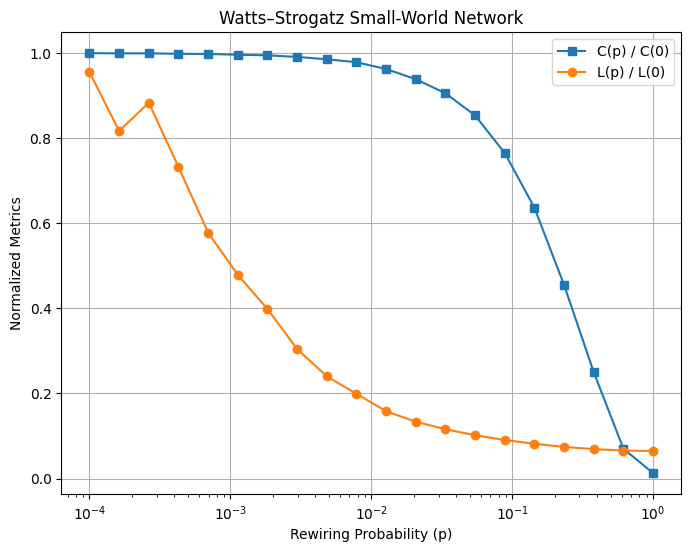

In [7]:
plt.figure(figsize=(8,6))

# Clustering coefficient
plt.semilogx(p_values, C_vals, 's-', label='C(p) / C(0)')

# Path length
plt.semilogx(p_values, L_vals, 'o-', label='L(p) / L(0)')

plt.xlabel('Rewiring Probability (p)')
plt.ylabel('Normalized Metrics')
plt.title('Watts–Strogatz Small-World Network')

plt.legend()
plt.grid(True)

plt.show()

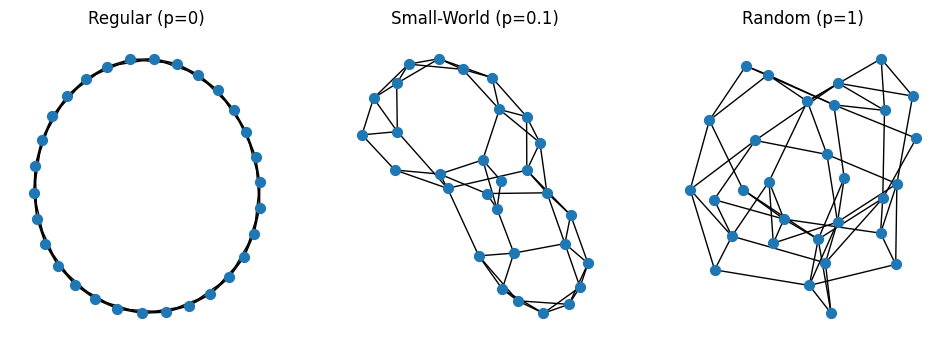

In [5]:
plt.figure(figsize=(12,4))

# Regular
G_reg = watts_strogatz_manual(30, 4, 0)
plt.subplot(1,3,1)
nx.draw(G_reg, node_size=50)
plt.title("Regular (p=0)")

# Small-world
G_sw = watts_strogatz_manual(30, 4, 0.1)
plt.subplot(1,3,2)
nx.draw(G_sw, node_size=50)
plt.title("Small-World (p=0.1)")

# Random
G_rand = watts_strogatz_manual(30, 4, 1)
plt.subplot(1,3,3)
nx.draw(G_rand, node_size=50)
plt.title("Random (p=1)")

plt.show()